gamma = 2.6051132213086143


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10936\4054967733.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


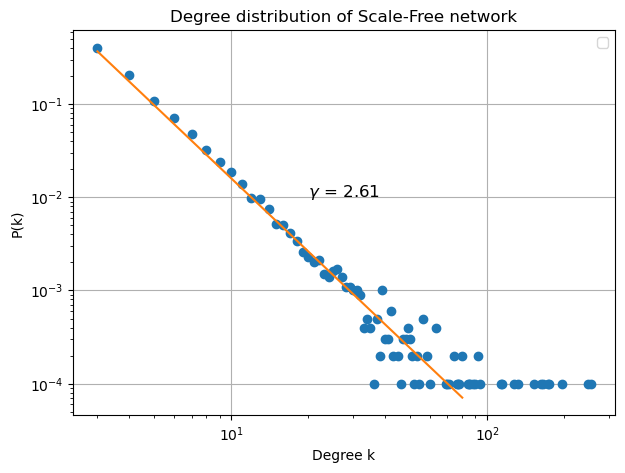

In [1]:
import numpy as np
import matplotlib.pyplot as plt



# read degrees
degree = np.loadtxt("scale_free_degree_list.txt")


# count how many nodes have each degree
k, counts = np.unique(degree, return_counts=True)


# probability distribution P(k)
Pk = counts / len(degree)


# remove zero values (log(0) is impossible)


mask = (k <= 80) & (k > 1)

k_fit = k[mask]
Pk_fit = Pk[mask]

coeff = np.polyfit(
    np.log(k_fit),
    np.log(Pk_fit),
    1
)

gamma =- coeff[0]


slope = coeff[0]
intercept = coeff[1]

print("gamma =", gamma)




# log-log plot
plt.figure(figsize=(7,5))

plt.loglog(k, Pk, 'o')

k_line = np.linspace(
    min(k_fit),
    max(k_fit),
    100
)
Pk_line = np.exp(slope*np.log(k_line) + intercept
)
plt.loglog(k_line, Pk_line )
plt.text(
    20,              # x-coordinate
    0.01,            # y-coordinate
    f"$\\gamma$ = {gamma:.2f}",
    fontsize=12
)
plt.xlabel("Degree k")
plt.ylabel("P(k)")
plt.title("Degree distribution of Scale-Free network")

plt.grid(True)
plt.legend()
plt.savefig(
    "scale_free_degree_distribution_loglog.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()